# MapleFreight Logistics: Delivery Delay Prediction and Slack Alerts

**Course:** AML 3303, Assessment 1
**Student:** Krushal Sardhara (Student ID: c0966419)
**Date:** 07 October 2026

This notebook builds a small end-to-end system. It cleans the raw shipment export, finds what drives late deliveries, trains a model that flags shipments likely to miss their delivery window, and posts the riskiest ones to a Slack channel so dispatch can act before the customer calls.

**Contents**
1. Context
2. Problem statement
3. Objectives
4. Setup
5. Data understanding
6. Data quality audit
7. Data preprocessing
8. Exploratory data analysis (EDA)
9. Feature engineering
10. Data preparation
11. Data modelling
12. Choosing the alert threshold
13. Model evaluation on the test set
14. Model explainability
15. Slack alert integration
16. Recommendations
17. Limitations and next steps

## 1. Context

MapleFreight Logistics moves about **8,000 shipments a week** across Ontario, Quebec and the Prairies. Most contracts come with an on-time guarantee, so every late delivery costs money in service credits and re-delivery charges.

On-time performance has fallen from **94% to 88%** this year. The bigger problem is timing: the company usually finds out a shipment is late only when the customer calls. By then the credit is already owed and the account manager hears about it before dispatch does.

## 2. Problem statement

Delays are only discovered after the delivery window has passed. I want to move that moment earlier.

The task is to predict, **at dispatch time**, which shipments are likely to arrive late, and to send dispatch a short Slack alert while there is still time to re-route the load or warn the customer. Because the prediction has to happen before delivery, the model can only use information that exists when the truck leaves. `actual_transit_hours` is recorded on delivery, so it cannot be used.

## 3. Objectives

1. Analyse shipment, route and carrier data to find the main drivers of late delivery.
2. Build a classifier that predicts `delivered_late` and compare it with a simple baseline.
3. Handle the class imbalance (about 21% late) and report precision, recall, F1 and a confusion matrix.
4. Choose an alert threshold that makes sense for the business, not just the default 0.5.
5. Send a real Slack message to `#dispatch-alerts` when high-risk shipments are found.
6. Give practical recommendations to improve on-time performance.

## 4. Setup

All libraries are standard and listed in `requirements.txt`. I fixed the random seed so the numbers in this notebook can be reproduced.

In [1]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import requests
from dotenv import load_dotenv

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (make_scorer, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, precision_recall_curve)

RANDOM_STATE = 42
DATA_PATH = "maplefreight_delivery_delay_dataset.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# One consistent colour scheme for every chart
ON_TIME, LATE, NEUTRAL = "#2a78d6", "#eb6834", "#8a8984"
DIVERGING = LinearSegmentedColormap.from_list("blue_grey_red", ["#2a78d6", "#f0efec", "#e34948"])
sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e1", "axes.edgecolor": "#c9c8c3",
                                     "axes.titleweight": "bold", "axes.titlesize": 11})
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded.")

Libraries loaded.


## 5. Data understanding

First I load the raw export and look at its shape, types and a few rows.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Rows: 6,035   Columns: 23


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,2,0,7.53,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,0,0,1.00,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,0,0,7.12,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,0,0,7.61,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,1,0,12.90,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [3]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "unique_values": raw.nunique(),
    "first_row": raw.iloc[0].astype(str),
})
overview

,dtype,missing,missing_%,unique_values,first_row
shipment_id,object,0,0.0,6000,SHP-103848
origin_city,object,0,0.0,7,Mississauga ON
destination_city,object,0,0.0,10,Edmonton AB
carrier,object,0,0.0,5,NorthStar Carriers
service_level,object,0,0.0,6,Standard
goods_type,object,0,0.0,5,General Freight
customer_priority_tier,object,0,0.0,3,Bronze
shipment_month,int64,0,0.0,12,1
distance_km,float64,0,0.0,4550,376.0
weight_kg,float64,0,0.0,5143,257.1


In [4]:
raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
shipment_month,6035.0,6.54,3.45,1.00,4.00,7.00,10.00,12.00
distance_km,6035.0,632.19,319.25,80.50,398.60,571.10,804.85,2556.70
weight_kg,6035.0,6928.25,83755.15,30.00,496.00,827.10,1286.30,2999300.00
num_stops,6035.0,2.48,1.71,0.00,1.00,2.00,4.00,5.00
is_cross_border,6035.0,0.11,0.32,0.00,0.00,0.00,0.00,1.00
scheduled_transit_hours,6035.0,10.50,4.76,1.00,7.06,9.85,13.18,37.40
pickup_delay_minutes,6035.0,20.37,30.62,-20.00,-6.00,18.00,41.00,146.00
driver_experience_years,5825.0,6.50,4.66,0.20,3.20,5.40,8.60,35.00
vehicle_age_years,6035.0,5.49,3.43,0.10,3.00,4.80,7.20,20.00
traffic_index,5914.0,55.15,17.59,5.00,43.30,55.00,67.20,100.00


In [5]:
late_share = raw["delivered_late"].mean()
print(raw["delivered_late"].value_counts().rename({0: "on time (0)", 1: "late (1)"}).to_string())
print(f"\nLate share: {late_share:.1%}")
print(f"Accuracy of a model that always says 'on time': {1 - late_share:.1%}")

delivered_late
on time (0)    4793
late (1)       1242

Late share: 20.6%
Accuracy of a model that always says 'on time': 79.4%


**Finding.** The file has 6,035 shipments and 23 columns: the shipment ID, 7 text columns and 15 numeric columns (including the target). About 20.6% of shipments were late, so the classes are imbalanced. A model that predicts "on time" for everything would already get 79% accuracy while catching zero late shipments, which is why I judge the models on precision, recall and F1 for the late class, not on accuracy.

The summary table already shows two warning signs. `weight_kg` has a maximum of almost 3 million kg, which is impossible for a truck, and four columns have missing values. The next section checks these problems one by one.

## 6. Data quality audit

The brief says the export is raw. I checked five things before cleaning anything: duplicates, inconsistent spellings, unit errors, missing values and leakage.

### 6.1 Duplicates

In [6]:
print(f"Exact duplicate rows:         {raw.duplicated().sum()}")
print(f"Repeated shipment_id values:  {raw['shipment_id'].duplicated().sum()}")

# IDs that still repeat after removing exact copies, i.e. the copies differ somewhere
no_exact = raw.drop_duplicates()
hidden_ids = no_exact.loc[no_exact["shipment_id"].duplicated(keep=False), "shipment_id"].unique()
print(f"IDs that repeat with small differences: {len(hidden_ids)}")
no_exact[no_exact["shipment_id"].isin(hidden_ids)].sort_values("shipment_id")[
    ["shipment_id", "service_level", "carrier", "destination_city", "distance_km", "delivered_late"]]

Exact duplicate rows:         32
Repeated shipment_id values:  35
IDs that repeat with small differences: 3


,shipment_id,service_level,carrier,destination_city,distance_km,delivered_late
861,SHP-101906,Express,NorthStar Carriers,Edmonton AB,333.7,0
3030,SHP-101906,standard,NorthStar Carriers,Edmonton AB,333.7,0
1228,SHP-102476,Standard,QuebecExpress,Montreal QC,949.0,1
4033,SHP-102476,standard,QuebecExpress,Montreal QC,949.0,1
441,SHP-103022,Standard,Contract Owner-Op,Regina SK,404.4,0
4375,SHP-103022,standard,Contract Owner-Op,Regina SK,404.4,0


There are 32 exact duplicate rows, but 35 repeated IDs. The other 3 IDs differ only in `service_level` ("standard" vs "Standard"), so they are the same shipment typed twice. One of them, SHP-101906, says "Express" in one copy and "standard" in the other. I cannot tell which is right, so I keep the first record. This also tells me the casing has to be fixed **before** dropping duplicates, otherwise two of these copies would slip through.

### 6.2 Inconsistent spellings

In [7]:
text_cols = ["origin_city", "destination_city", "carrier", "service_level",
             "goods_type", "customer_priority_tier", "weather_condition"]
for col in text_cols:
    print(f"{col:24s} {sorted(raw[col].dropna().unique())}")

origin_city              ['Calgary AB', 'London ON', 'Mississauga ON', 'Montreal QC', 'Ottawa ON', 'Toronto ON', 'Winnipeg MB']
destination_city         ['Calgary AB', 'Edmonton AB', 'Hamilton ON', 'Montreal QC', 'Ottawa ON', 'Quebec City QC', 'Regina SK', 'Sudbury ON', 'Toronto ON', 'Winnipeg MB']
carrier                  ['Contract Owner-Op', 'MapleFreight Fleet', 'NorthStar Carriers', 'PrairieLine', 'QuebecExpress']
service_level            ['Economy', 'Express', 'Standard', 'economy', 'express', 'standard']
goods_type               ['Bulk', 'Fragile', 'General Freight', 'Hazardous', 'Refrigerated']
customer_priority_tier   ['Bronze', 'Gold', 'Silver']
weather_condition        ['Clear', 'Fog', 'Rain', 'Snow', 'Storm']


Only `service_level` has a problem: 120 rows use lower case ("standard", "express", "economy"). Cities, carriers and goods types are already consistent, and I found no extra spaces. Without a fix, a model would treat "standard" and "Standard" as two different service levels.

### 6.3 Unit errors

count       6035.0
mean        6928.3
std        83755.1
min           30.0
50%          827.1
90%         1849.5
99%         3360.6
99.5%     535051.0
max      2999300.0

Rows above 20,000 kg: 40  (from 170,900 to 2,999,300)
Largest normal weight: 5,044 kg
Same rows divided by 1,000: 170.9 to 2,999.3 kg


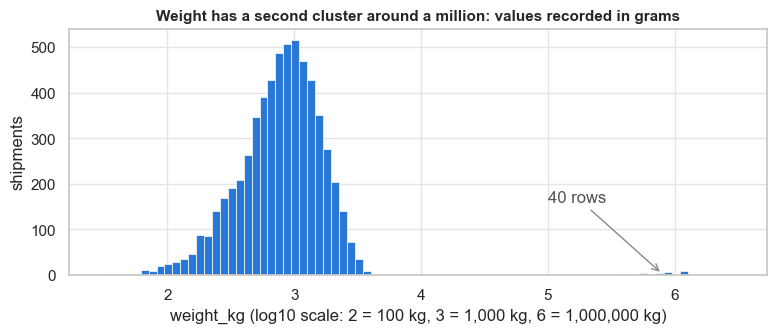

In [8]:
w = raw["weight_kg"]
print(w.describe(percentiles=[0.5, 0.9, 0.99, 0.995]).round(1).to_string())

heavy = raw.loc[w > 20_000, "weight_kg"]
normal_max = w[w <= 20_000].max()
print(f"\nRows above 20,000 kg: {len(heavy)}  (from {heavy.min():,.0f} to {heavy.max():,.0f})")
print(f"Largest normal weight: {normal_max:,.0f} kg")
print(f"Same rows divided by 1,000: {heavy.min()/1000:,.1f} to {heavy.max()/1000:,.1f} kg")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(np.log10(w), bins=80, color=ON_TIME, edgecolor="white", linewidth=0.5)
ax.set_xlabel("weight_kg (log10 scale: 2 = 100 kg, 3 = 1,000 kg, 6 = 1,000,000 kg)")
ax.set_ylabel("shipments")
ax.set_title("Weight has a second cluster around a million: values recorded in grams")
ax.annotate(f"{len(heavy)} rows", xy=(5.9, 3), xytext=(5.0, 160),
            arrowprops=dict(arrowstyle="->", color=NEUTRAL), color="#52514e")
plt.show()

Normal shipments weigh between 30 kg and about 5,000 kg. Then there is a separate group of 40 rows between 170,900 and 2,999,300. If I divide these by 1,000 they land between 171 and 2,999 kg, right inside the normal range. That pattern points to a unit error (grams typed into a kilograms field), so I convert them instead of deleting them. I also checked distance against scheduled hours and fuel cost for a similar km/miles mix-up but did not find one.

### 6.4 Missing values

In [9]:
missing_cols = [c for c in raw.columns if raw[c].isna().any()]
pd.DataFrame({
    "missing_rows": raw[missing_cols].isna().sum(),
    "missing_%": (raw[missing_cols].isna().mean() * 100).round(1),
    "late_rate_if_missing": [raw.loc[raw[c].isna(), "delivered_late"].mean() for c in missing_cols],
    "late_rate_if_present": [raw.loc[raw[c].notna(), "delivered_late"].mean() for c in missing_cols],
}).round(3)

,missing_rows,missing_%,late_rate_if_missing,late_rate_if_present
driver_experience_years,210,3.5,0.224,0.205
weather_condition,150,2.5,0.220,0.205
traffic_index,121,2.0,0.182,0.206
fuel_cost_cad,240,4.0,0.192,0.206


Four columns have gaps, all below 4%. The late rate is about the same whether a value is missing or not, so the gaps look random rather than meaningful. My plan:

* `weather_condition`: fill with a new category **"Unknown"**. Guessing "Clear" would hide the fact that the forecast was missing.
* `driver_experience_years`, `traffic_index`, `fuel_cost_cad`: fill with the **median**, but inside the model pipeline, so the median comes from the training data only and nothing leaks from the test set.

### 6.5 Leakage and other checks

In [10]:
overrun = raw["actual_transit_hours"] - raw["scheduled_transit_hours"]
bins = pd.cut(overrun, [-np.inf, 0, 0.5, 1, 2, np.inf],
              labels=["early or on schedule", "0 to 0.5 h over", "0.5 to 1 h over", "1 to 2 h over", "more than 2 h over"])
print(pd.crosstab(bins, raw["delivered_late"], margins=True).rename(columns={0: "on time", 1: "late"}))

print(f"\nPickups exactly 20 min early (the lowest value): {(raw['pickup_delay_minutes'] == -20).sum()}")
print(f"Shipments where origin city = destination city:  {(raw['origin_city'] == raw['destination_city']).sum()}")

delivered_late        on time  late   All
row_0                                    
early or on schedule     3218     0  3218
0 to 0.5 h over          1303     4  1307
0.5 to 1 h over           256    29   285
1 to 2 h over              16   179   195
more than 2 h over          0  1030  1030
All                      4793  1242  6035

Pickups exactly 20 min early (the lowest value): 846
Shipments where origin city = destination city:  466


`actual_transit_hours` basically **is** the target: almost every shipment that ran more than an hour over schedule is labelled late, and none that ran early are. It is only known after delivery, so I drop it from the features. Keeping it would give a great score in the notebook and a useless model in real life.

Two other things look odd but are not clearly wrong, so I left them alone. Early pickups stop at exactly -20 minutes (846 rows), which looks like the system caps early arrivals. And 466 shipments start and end in the same city. These could be local multi-drop routes. The city columns end up with almost no predictive value anyway (Section 8).

## 7. Data preprocessing

All the fixes go into one function so the same steps can be applied to new data later. The order matters: casing first, then duplicates.

In [11]:
TEXT_COLS = ["shipment_id", "origin_city", "destination_city", "carrier", "service_level",
             "goods_type", "customer_priority_tier", "weather_condition"]

def clean_shipments(df):
    """Clean the raw MapleFreight export. Returns the clean data and a log of what changed."""
    df = df.copy()
    log = []

    # 1. Tidy text: remove stray spaces and use one spelling for service_level
    for col in TEXT_COLS:
        df[col] = df[col].str.strip()
    fixed = (df["service_level"] != df["service_level"].str.title()).sum()
    df["service_level"] = df["service_level"].str.title()
    log.append(("Fixed service_level casing ('standard' -> 'Standard')", fixed))

    # 2. Duplicates (after the casing fix, so hidden copies match exactly)
    before = len(df)
    df = df.drop_duplicates()
    log.append(("Dropped exact duplicate rows", before - len(df)))
    before = len(df)
    df = df.drop_duplicates(subset="shipment_id", keep="first")
    log.append(("Dropped conflicting copies of the same shipment_id (kept first)", before - len(df)))

    # 3. Unit error: weights recorded in grams
    grams = df["weight_kg"] > 20_000
    df.loc[grams, "weight_kg"] = df.loc[grams, "weight_kg"] / 1000
    log.append(("Converted weight_kg recorded in grams (divided by 1,000)", int(grams.sum())))

    # 4. Missing forecast becomes its own category
    no_weather = df["weather_condition"].isna().sum()
    df["weather_condition"] = df["weather_condition"].fillna("Unknown")
    log.append(("Filled missing weather_condition with 'Unknown'", no_weather))

    log.append(("Numeric gaps left for the pipeline's median imputer",
                int(df[["driver_experience_years", "traffic_index", "fuel_cost_cad"]].isna().sum().sum())))
    return df.reset_index(drop=True), pd.DataFrame(log, columns=["cleaning step", "rows affected"])

clean, cleaning_log = clean_shipments(raw)
display(cleaning_log)

assert clean["shipment_id"].is_unique
assert clean["weight_kg"].max() < 20_000
print(f"Rows before: {len(raw):,}   after: {len(clean):,}   late share now: {clean['delivered_late'].mean():.1%}")

,cleaning step,rows affected
0,Fixed service_level casing ('standard' -> 'Sta...,120
1,Dropped exact duplicate rows,34
2,Dropped conflicting copies of the same shipmen...,1
3,Converted weight_kg recorded in grams (divided...,40
4,Filled missing weather_condition with 'Unknown',150
5,Numeric gaps left for the pipeline's median im...,570


Rows before: 6,035   after: 6,000   late share now: 20.6%


**Finding.** After cleaning there are 6,000 unique shipments. 35 duplicates were removed (34 exact copies once the casing was fixed, plus 1 conflicting copy), 40 weights were converted from grams, and the missing forecasts are now an explicit "Unknown" category. The late share stays at 20.6%, so cleaning did not change the balance of the target.

## 8. Exploratory data analysis (EDA)

Here I look for the factors that separate late shipments from on-time ones. I use the late rate (share of shipments that arrived late) for each group, with the overall rate of 20.6% as a reference line.

### 8.1 Target balance

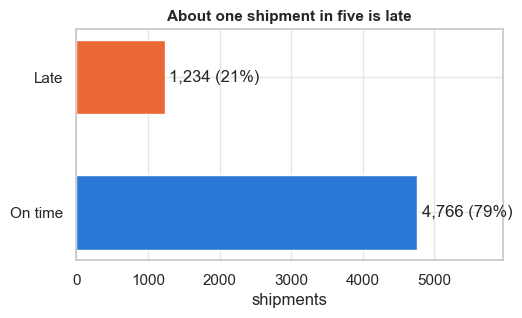

In [12]:
overall = clean["delivered_late"].mean()
counts = clean["delivered_late"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5.5, 3))
bars = ax.barh(["On time", "Late"], counts.values, color=[ON_TIME, LATE], height=0.55)
for b, n in zip(bars, counts.values):
    ax.text(b.get_width() + 60, b.get_y() + b.get_height() / 2, f"{n:,} ({n/len(clean):.0%})", va="center")
ax.set_xlim(0, counts.max() * 1.25)
ax.set_xlabel("shipments")
ax.set_title("About one shipment in five is late")
plt.show()

### 8.2 Late rate by category

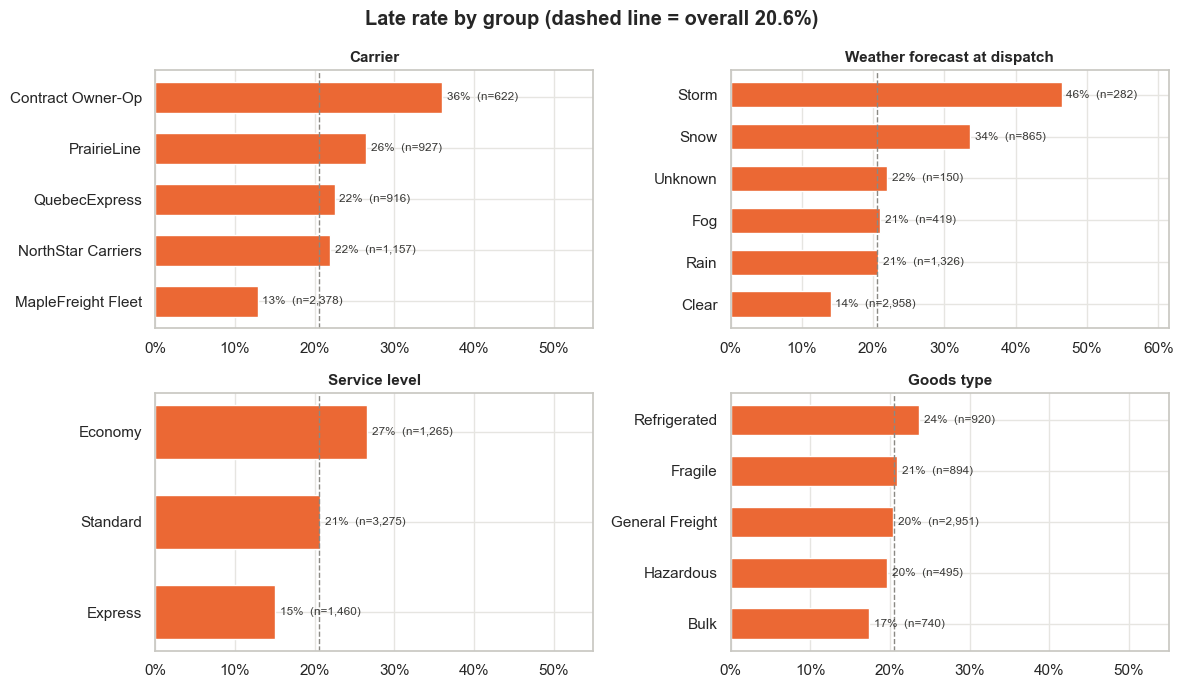

In [13]:
def late_rate(df, col):
    return (df.groupby(col)["delivered_late"].agg(late_rate="mean", shipments="size")
              .sort_values("late_rate"))

def plot_rate(ax, table, title):
    ax.barh(table.index.astype(str), table["late_rate"], color=LATE, height=0.6)
    ax.axvline(overall, color=NEUTRAL, ls="--", lw=1)
    for i, (r, n) in enumerate(zip(table["late_rate"], table["shipments"])):
        ax.text(r + 0.006, i, f"{r:.0%}  (n={n:,})", va="center", fontsize=8.5, color="#3a3a38")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_xlim(0, max(0.55, table["late_rate"].max() + 0.15))
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, title) in zip(axes.ravel(), [
        ("carrier", "Carrier"), ("weather_condition", "Weather forecast at dispatch"),
        ("service_level", "Service level"), ("goods_type", "Goods type")]):
    plot_rate(ax, late_rate(clean, col), title)
fig.suptitle("Late rate by group (dashed line = overall 20.6%)", fontweight="bold")
fig.tight_layout()
plt.show()

**Finding.** Carrier and weather show the biggest gaps.

* **Carrier:** contract owner-operators are late on about 36% of loads, almost three times the company's own fleet (13%). PrairieLine is also above average at 26%.
* **Weather:** the late rate rises steadily from clear (14%) to snow (34%) and storm (46%). A storm forecast more than triples the risk compared with clear weather.
* **Service level:** Express is late least often (15%) and Economy most often (27%). This makes sense if Express loads get priority at the dock.
* **Goods type:** refrigerated loads are slightly worse (24%), and the other types sit close to the average.

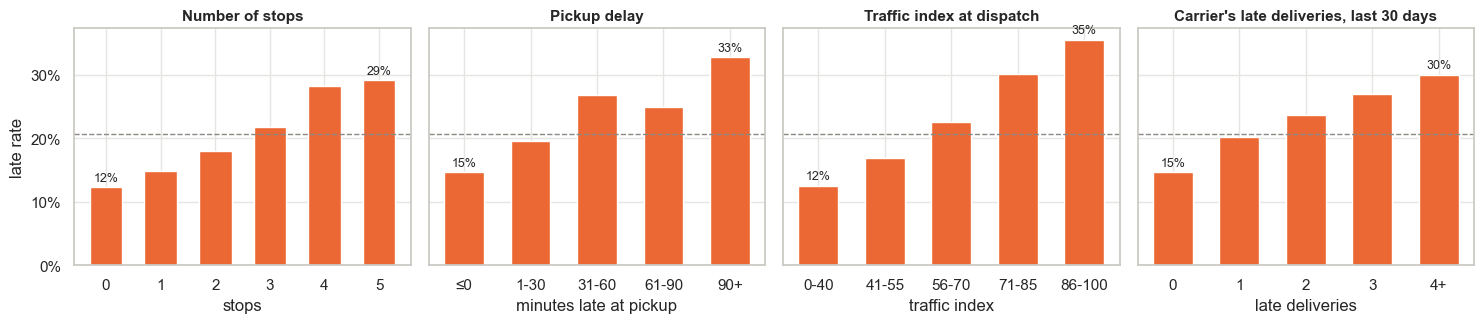

In [14]:
grp = clean.assign(
    pickup_delay=pd.cut(clean["pickup_delay_minutes"], [-21, 0, 30, 60, 90, 150],
                        labels=["≤0", "1-30", "31-60", "61-90", "90+"]),
    traffic=pd.cut(clean["traffic_index"], [0, 40, 55, 70, 85, 100],
                   labels=["0-40", "41-55", "56-70", "71-85", "86-100"]),
    carrier_late_30d=clean["prior_late_deliveries_30d"].clip(upper=4).map(lambda v: "4+" if v == 4 else str(v)),
)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, (col, title, xlabel) in zip(axes, [
        ("num_stops", "Number of stops", "stops"),
        ("pickup_delay", "Pickup delay", "minutes late at pickup"),
        ("traffic", "Traffic index at dispatch", "traffic index"),
        ("carrier_late_30d", "Carrier's late deliveries, last 30 days", "late deliveries")]):
    t = grp.groupby(col, observed=True)["delivered_late"].mean()
    ax.bar(t.index.astype(str), t.values, color=LATE, width=0.6)
    ax.axhline(overall, color=NEUTRAL, ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.text(len(t) - 1, t.values[-1] + 0.01, f"{t.values[-1]:.0%}", ha="center", fontsize=9)
    ax.text(0, t.values[0] + 0.01, f"{t.values[0]:.0%}", ha="center", fontsize=9)
axes[0].set_ylabel("late rate")
fig.tight_layout()
plt.show()

**Finding.** Four operational numbers all push the risk up in a steady, almost straight-line way:

* Each extra stop adds risk: 12% with no stops, 29% with five.
* A pickup that is more than 90 minutes late has a 34% late rate, compared with 15% for early or on-time pickups. Time lost at pickup is hard to win back on the road.
* Heavy traffic at dispatch (index above 85) raises the late rate to 35%.
* A carrier that was late 4 or more times in the past 30 days is late again about 30% of the time.

These steady trends suggest a linear model could work well here, which I test in Section 11.

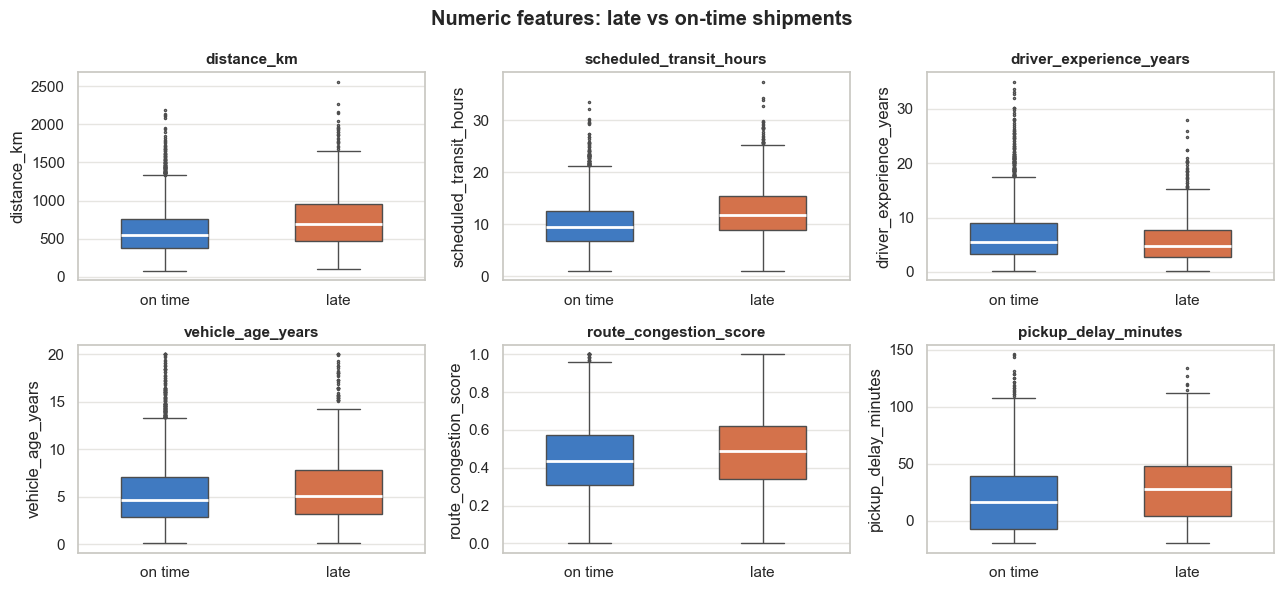

In [15]:
num_view = ["distance_km", "scheduled_transit_hours", "driver_experience_years",
            "vehicle_age_years", "route_congestion_score", "pickup_delay_minutes"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), num_view):
    sns.boxplot(data=clean, x="delivered_late", y=col, hue="delivered_late", ax=ax, width=0.5,
                palette={0: ON_TIME, 1: LATE}, legend=False, fliersize=1.5,
                medianprops=dict(color="white", lw=2))
    ax.set_xticks([0, 1], ["on time", "late"])
    ax.set_xlabel("")
    ax.set_title(col)
fig.suptitle("Numeric features: late vs on-time shipments", fontweight="bold")
fig.tight_layout()
plt.show()

**Finding.** Late shipments tend to travel further and have longer scheduled times, they get slightly less experienced drivers and older trucks, and they run on routes with a higher congestion history. None of these alone separates the two groups cleanly (the boxes overlap a lot), so the model will need to combine several signals.

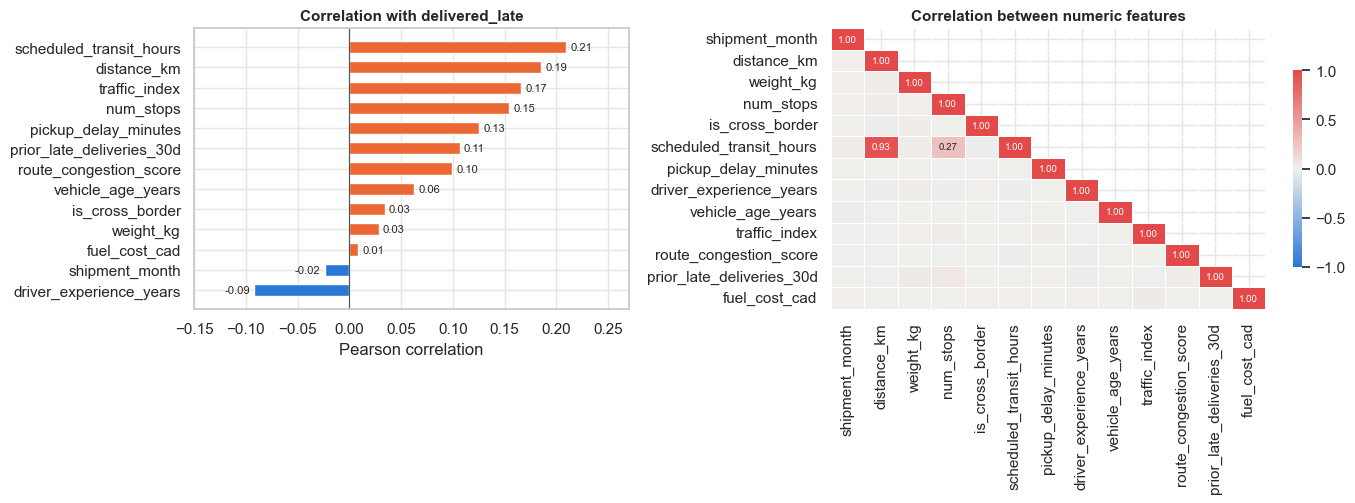

In [16]:
num_cols = clean.select_dtypes("number").columns.drop(["delivered_late", "actual_transit_hours"])
corr_target = clean[num_cols].corrwith(clean["delivered_late"]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})
axes[0].barh(corr_target.index, corr_target.values,
             color=[LATE if v > 0 else ON_TIME for v in corr_target.values], height=0.6)
axes[0].axvline(0, color="#52514e", lw=0.8)
axes[0].set_title("Correlation with delivered_late")
axes[0].set_xlabel("Pearson correlation")
for i, v in enumerate(corr_target.values):
    axes[0].text(v + (0.004 if v >= 0 else -0.004), i, f"{v:.2f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)
axes[0].set_xlim(-0.15, 0.27)

corr_matrix = clean[num_cols].corr()
labels = corr_matrix.map(lambda v: f"{v:.2f}" if abs(v) >= 0.1 else "")  # only label the notable pairs
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, ax=axes[1],
            annot=labels, fmt="", annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, linewidths=0.5)
axes[1].set_title("Correlation between numeric features")
fig.tight_layout()
plt.show()

**Finding.** Scheduled transit hours, distance, traffic and number of stops have the strongest positive link with lateness. Driver experience is the only clear protective factor. `distance_km` and `scheduled_transit_hours` are strongly correlated with each other (0.93), because the schedule is mostly distance plus time for stops. That is fine for prediction but it means their individual coefficients should be read with care. `weight_kg` and `fuel_cost_cad` show essentially no relationship with lateness.

In [17]:
check_cols = ["weather_condition", "carrier", "service_level", "num_stops", "goods_type",
              "shipment_month", "destination_city", "origin_city", "customer_priority_tier"]
spread = pd.DataFrame({c: clean.groupby(c)["delivered_late"].mean().agg(["min", "max"]) for c in check_cols}).T
spread["gap_points"] = ((spread["max"] - spread["min"]) * 100).round(1)
spread[["min", "max"]] = (spread[["min", "max"]] * 100).round(1)
spread.rename(columns={"min": "lowest_group_%", "max": "highest_group_%"}).sort_values("gap_points", ascending=False)

,lowest_group_%,highest_group_%,gap_points
weather_condition,14.1,46.5,32.4
carrier,12.8,36.0,23.2
num_stops,12.3,29.1,16.8
service_level,15.1,26.6,11.5
shipment_month,17.7,24.9,7.2
goods_type,17.4,23.7,6.3
destination_city,19.0,23.3,4.2
origin_city,19.0,21.6,2.6
customer_priority_tier,20.4,20.7,0.3


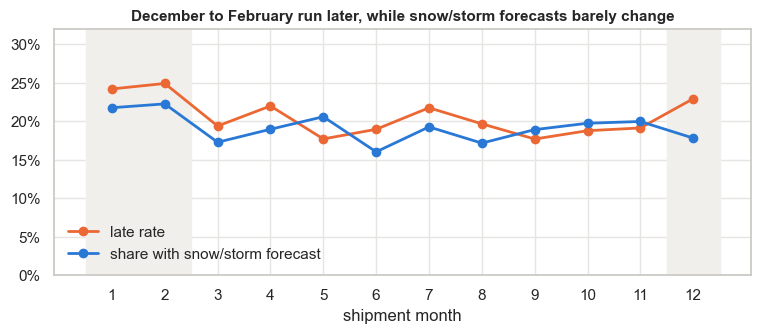

Late rate, Dec-Feb vs other months:               24.0% vs 19.4%
Share of snow/storm forecasts, Dec-Feb vs others:  20.5% vs 18.6%
Late rate on CLEAR-forecast days, Dec-Feb vs others: 16.9% vs 13.1%


In [18]:
monthly = clean.groupby("shipment_month").agg(late_rate=("delivered_late", "mean"),
                                              snow_or_storm=("weather_condition", lambda s: s.isin(["Snow", "Storm"]).mean()))
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(monthly.index, monthly["late_rate"], color=LATE, lw=2, marker="o", ms=6, label="late rate")
ax.plot(monthly.index, monthly["snow_or_storm"], color=ON_TIME, lw=2, marker="o", ms=6, label="share with snow/storm forecast")
ax.axvspan(0.5, 2.5, color="#f0efec"); ax.axvspan(11.5, 12.5, color="#f0efec")
ax.set_xticks(range(1, 13))
ax.set_xlabel("shipment month")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 0.32)
ax.legend(loc="lower left", frameon=False)
ax.set_title("December to February run later, while snow/storm forecasts barely change")
plt.show()

winter = clean["shipment_month"].isin([12, 1, 2])
is_clear = clean["weather_condition"] == "Clear"
print(f"Late rate, Dec-Feb vs other months:               {clean.loc[winter, 'delivered_late'].mean():.1%} vs {clean.loc[~winter, 'delivered_late'].mean():.1%}")
print(f"Share of snow/storm forecasts, Dec-Feb vs others:  {clean.loc[winter, 'weather_condition'].isin(['Snow', 'Storm']).mean():.1%} vs {clean.loc[~winter, 'weather_condition'].isin(['Snow', 'Storm']).mean():.1%}")
print(f"Late rate on CLEAR-forecast days, Dec-Feb vs others: {clean.loc[winter & is_clear, 'delivered_late'].mean():.1%} vs {clean.loc[~winter & is_clear, 'delivered_late'].mean():.1%}")

**Finding.** The gap table separates useful columns from noise. Weather, carrier, service level and stops move the late rate by 10 to 32 percentage points. Customer tier (Gold, Silver, Bronze) moves it by less than half a point and the cities by only 3 to 4 points, so they carry little information. This is a useful business point as well: Gold customers are **not** getting better on-time service than Bronze customers.

Month is interesting. December, January and February have higher late rates (23 to 25%), but the share of snow or storm forecasts is only about 2 points higher than in the rest of the year, which is far too small to explain the gap. Even on days with a **clear** forecast, winter shipments are late 17% of the time against 13% in other months. So winter seems to add risk beyond the forecast itself (shorter days, icy roads, holiday volume). I turn this into a feature in the next section.

## 9. Feature engineering

I created five candidate features. Every one of them can be calculated when the truck leaves, so none of them leaks future information.

| Feature | Idea |
|---|---|
| `winter_month` | 1 for December, January, February (the EDA showed extra risk in these months) |
| `severe_weather` | 1 if the forecast is snow or storm |
| `planned_speed_kmh` | distance / scheduled hours. A high value means a tight schedule |
| `pickup_delay_share` | hours lost at pickup as a share of the scheduled transit time |
| `traffic_x_congestion` | today's traffic multiplied by the route's congestion history |

In [19]:
def add_features(df):
    df = df.copy()
    df["winter_month"] = df["shipment_month"].isin([12, 1, 2]).astype(int)
    df["severe_weather"] = df["weather_condition"].isin(["Snow", "Storm"]).astype(int)
    df["planned_speed_kmh"] = df["distance_km"] / df["scheduled_transit_hours"]
    df["pickup_delay_share"] = (df["pickup_delay_minutes"].clip(lower=0) / 60) / df["scheduled_transit_hours"]
    df["traffic_x_congestion"] = df["traffic_index"] * df["route_congestion_score"]
    return df

data = add_features(clean)
ENGINEERED = ["winter_month", "severe_weather", "planned_speed_kmh", "pickup_delay_share", "traffic_x_congestion"]

summary = pd.DataFrame({
    "correlation_with_late": data[ENGINEERED].corrwith(data["delivered_late"]).round(3),
    "late_rate_when_1": [data.loc[data[c] == 1, "delivered_late"].mean() if data[c].nunique() == 2 else np.nan
                         for c in ENGINEERED],
    "late_rate_when_0": [data.loc[data[c] == 0, "delivered_late"].mean() if data[c].nunique() == 2 else np.nan
                         for c in ENGINEERED],
}).round(3)
summary

,correlation_with_late,late_rate_when_1,late_rate_when_0
winter_month,0.049,0.240,0.194
severe_weather,0.195,0.368,0.167
planned_speed_kmh,-0.043,NaN,NaN
pickup_delay_share,0.003,NaN,NaN
traffic_x_congestion,0.174,NaN,NaN


**Finding.** `severe_weather` and `winter_month` are clear signals on their own: severe weather shipments are late 37% of the time against 17% otherwise, and winter shipments 24% against 19%. `traffic_x_congestion` is about as strong as traffic alone. The two ratio features turned out weak. `planned_speed_kmh` has almost no link with lateness because the schedule already adjusts for distance and stops, and `pickup_delay_share` is weaker than the raw pickup delay. Whether a feature actually helps the model is tested properly with cross-validation in Section 11, since a good correlation does not always mean extra information.

## 10. Data preparation

* **Target:** `delivered_late`.
* **Removed:** `actual_transit_hours` (leakage) and `shipment_id` (just an ID, but I keep it alongside the data for the Slack alert).
* **Split:** 80% training and 20% test, stratified so both parts keep the 20.6% late share. The test set is not touched until Section 13.
* **Pipeline:** median imputation and scaling for numeric columns, one-hot encoding for text columns. Everything sits inside a scikit-learn `Pipeline`, so imputation values and scaling are learned from the training folds only.

I prepare two feature sets: **all** columns (raw + engineered) and a **selected** set that drops the columns the EDA showed to be noise (cities, customer tier, weight, fuel cost) and the weak engineered features.

In [20]:
TARGET = "delivered_late"
LEAKAGE = ["actual_transit_hours"]

RAW_CAT = ["origin_city", "destination_city", "carrier", "service_level", "goods_type",
           "customer_priority_tier", "weather_condition"]
RAW_NUM = ["shipment_month", "distance_km", "weight_kg", "num_stops", "is_cross_border",
           "scheduled_transit_hours", "pickup_delay_minutes", "driver_experience_years",
           "vehicle_age_years", "traffic_index", "route_congestion_score",
           "prior_late_deliveries_30d", "fuel_cost_cad"]

SEL_CAT = ["carrier", "service_level", "goods_type", "weather_condition"]
SEL_NUM = ["distance_km", "num_stops", "is_cross_border", "scheduled_transit_hours",
           "pickup_delay_minutes", "driver_experience_years", "vehicle_age_years",
           "traffic_index", "route_congestion_score", "prior_late_deliveries_30d", "winter_month"]

X = data.drop(columns=[TARGET] + LEAKAGE)
y = data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

def make_preprocessor(cat_cols, num_cols, scale=True):
    num_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ])

print(f"Training set: {len(X_train):,} shipments, late share {y_train.mean():.1%}")
print(f"Test set:     {len(X_test):,} shipments, late share {y_test.mean():.1%}")
print(f"All features: {len(RAW_CAT) + len(RAW_NUM) + len(ENGINEERED)} columns   Selected: {len(SEL_CAT) + len(SEL_NUM)} columns")

Training set: 4,800 shipments, late share 20.6%
Test set:     1,200 shipments, late share 20.6%
All features: 25 columns   Selected: 15 columns


## 11. Data modelling

### 11.1 How I compare models

Every model is scored with 5-fold stratified cross-validation on the training set only. I report:

* **ROC-AUC** and **PR-AUC** (average precision): how well the model ranks late shipments above on-time ones, independent of any threshold. PR-AUC is the more honest one when the positive class is small.
* **Precision, recall and F1 for the late class** at the default 0.5 threshold. The real threshold is chosen later in Section 12.

**Handling the imbalance.** I use `class_weight="balanced"`, which makes each late shipment count about four times as much as an on-time one during training. I also tune the decision threshold afterwards. I chose this over SMOTE because it does not create synthetic shipments and needs no extra library. To show that it matters, the baseline is trained **without** any weighting.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy",
}

def cv_summary(name, model):
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    return {"model": name, **{k: s[f"test_{k}"].mean() for k in SCORING}}

results = []

### 11.2 Baselines

1. **Dummy classifier**: always predicts "on time". This is the 79% accuracy trap from the brief.
2. **Baseline logistic regression**: all cleaned columns, no class weighting, threshold 0.5. This is the simple model that everything else has to beat.

In [22]:
dummy = DummyClassifier(strategy="most_frequent")
baseline = Pipeline([
    ("prep", make_preprocessor(RAW_CAT, RAW_NUM)),
    ("model", LogisticRegression(max_iter=2000)),
])

results.append(cv_summary("Dummy (always on time)", dummy))
results.append(cv_summary("Baseline LR (all raw columns, no weighting)", baseline))
pd.DataFrame(results).set_index("model").round(3)

,roc_auc,pr_auc,precision,recall,f1,accuracy
model,,,,,,
Dummy (always on time),0.500,0.206,0.000,0.000,0.000,0.794
"Baseline LR (all raw columns, no weighting)",0.811,0.563,0.631,0.329,0.432,0.822


The dummy model gets 79.4% accuracy but zero recall, so it never catches a late shipment. The baseline logistic regression ranks shipments reasonably well (ROC-AUC 0.81), but at the 0.5 threshold it only catches about a third of late shipments (recall 0.33). Most late loads would still be a surprise to dispatch.

### 11.3 Candidate models

I tried four improvements:

* **LR balanced, all features:** same model, with class weights and the engineered features.
* **LR balanced, selected features:** fewer, cleaner inputs. I tuned the regularisation strength `C` with a grid search.
* **Random forest** (balanced) on all features.
* **Histogram gradient boosting** (balanced) on all features, with a small grid search over learning rate and tree depth.

In [23]:
ALL_CAT, ALL_NUM = RAW_CAT, RAW_NUM + ENGINEERED

lr_all = Pipeline([
    ("prep", make_preprocessor(ALL_CAT, ALL_NUM)),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced")),
])

lr_sel_search = GridSearchCV(
    Pipeline([("prep", make_preprocessor(SEL_CAT, SEL_NUM)),
              ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))]),
    param_grid={"model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
    scoring="average_precision", cv=cv, n_jobs=-1).fit(X_train, y_train)
print("Best C for selected-feature LR:", lr_sel_search.best_params_["model__C"])

rf = Pipeline([
    ("prep", make_preprocessor(ALL_CAT, ALL_NUM, scale=False)),
    ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
                                     n_jobs=-1, random_state=RANDOM_STATE)),
])

hgb_search = GridSearchCV(
    Pipeline([("prep", make_preprocessor(ALL_CAT, ALL_NUM, scale=False)),
              ("model", HistGradientBoostingClassifier(max_iter=300, min_samples_leaf=40, l2_regularization=1.0,
                                                       class_weight="balanced", random_state=RANDOM_STATE))]),
    param_grid={"model__learning_rate": [0.03, 0.1], "model__max_depth": [2, 4]},
    scoring="average_precision", cv=cv, n_jobs=-1).fit(X_train, y_train)
print("Best gradient boosting settings:", hgb_search.best_params_)

results.append(cv_summary("LR balanced (all + engineered)", lr_all))
results.append(cv_summary("LR balanced (selected features, tuned C)", lr_sel_search.best_estimator_))
results.append(cv_summary("Random forest balanced (all + engineered)", rf))
results.append(cv_summary("Gradient boosting balanced (all + engineered, tuned)", hgb_search.best_estimator_))

comparison = pd.DataFrame(results).set_index("model").round(3)
comparison

Best C for selected-feature LR: 3
Best gradient boosting settings: {'model__learning_rate': 0.03, 'model__max_depth': 2}


,roc_auc,pr_auc,precision,recall,f1,accuracy
model,,,,,,
Dummy (always on time),0.500,0.206,0.000,0.000,0.000,0.794
"Baseline LR (all raw columns, no weighting)",0.811,0.563,0.631,0.329,0.432,0.822
LR balanced (all + engineered),0.809,0.561,0.420,0.723,0.531,0.737
"LR balanced (selected features, tuned C)",0.817,0.571,0.425,0.744,0.541,0.740
Random forest balanced (all + engineered),0.793,0.526,0.562,0.379,0.451,0.810
"Gradient boosting balanced (all + engineered, tuned)",0.797,0.538,0.407,0.690,0.511,0.728


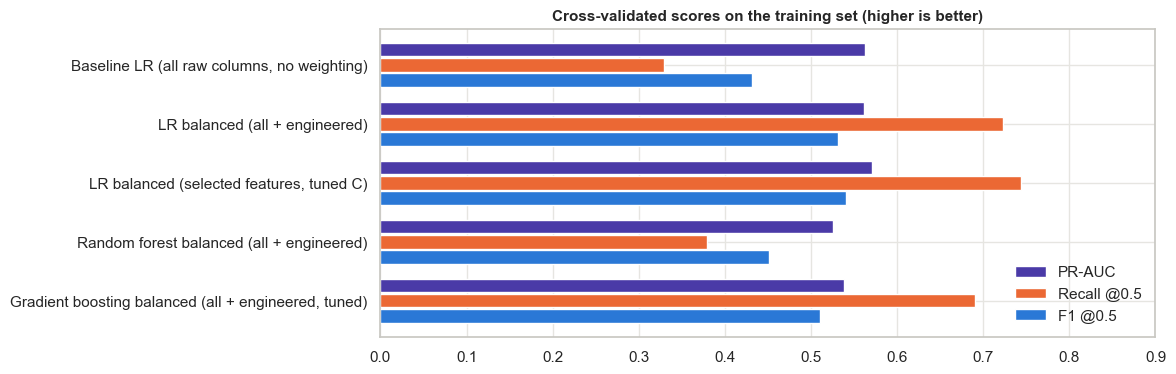

In [24]:
plot_df = comparison.drop(index="Dummy (always on time)")[["pr_auc", "recall", "f1"]].iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 4))
yy = np.arange(len(plot_df))
h = 0.26
for i, (col, colour, label) in enumerate([("pr_auc", "#4a3aa7", "PR-AUC"), ("recall", LATE, "Recall @0.5"), ("f1", ON_TIME, "F1 @0.5")]):
    ax.barh(yy + (1 - i) * h, plot_df[col], height=h - 0.03, color=colour, label=label)
ax.set_yticks(yy, plot_df.index)
ax.set_xlim(0, 0.9)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Cross-validated scores on the training set (higher is better)")
plt.show()

**Finding.**

* **Class weighting is the big win.** Turning it on lifts recall at 0.5 from 0.33 to 0.74, and F1 from 0.43 to 0.54. The ranking quality (ROC-AUC) barely changes, which is expected: weighting moves the decision point, it does not make the model smarter.
* **The tree models did not beat logistic regression.** Even after tuning, random forest (PR-AUC 0.52) and gradient boosting (0.54) score below the logistic regression (0.57). The EDA showed that each driver raises the risk in a steady, additive way, and that is exactly what a logistic regression captures. With 4,800 training rows, the extra flexibility of trees mostly fits noise.
* **Fewer features worked slightly better.** Adding the engineered features to every column did not help (PR-AUC 0.561). Dropping the noise columns and keeping only `winter_month` from the new features gave the best ROC-AUC (0.817) and PR-AUC (0.571), with a simpler model that dispatch can understand.

**Final model: balanced logistic regression on the selected features.** It is the most accurate of the candidates, it is fast, and every prediction can be explained with its coefficients.

## 12. Choosing the alert threshold

The 0.5 cut-off is just a default. The right threshold depends on what each kind of mistake costs:

* A **missed late shipment** (false negative) means a service credit, maybe a re-delivery, and an angry customer.
* A **false alarm** (false positive) costs a dispatcher a few minutes to check the load or call the customer.

I do not have MapleFreight's real cost figures, so I made reasonable assumptions and wrote them down so they can be replaced:

| Assumption | Value |
|---|---|
| Average cost of a late delivery (credit + re-delivery) | about CAD 250 |
| Share of that cost dispatch can avoid with early warning | about half, so **CAD 125 saved per late shipment caught** |
| Cost of handling one alert (15 to 20 min of dispatcher time) | **CAD 20** per alert, right or wrong |
| Minimum precision, so dispatch keeps trusting the alerts | **0.45** (at least 9 real problems in every 20 alerts) |

To avoid tuning on the test set, I choose the threshold from **out-of-fold predictions** on the training set: every training shipment is scored by a model that did not see it.

In [25]:
final_model = lr_sel_search.best_estimator_
oof_score = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

WEEKLY_SHIPMENTS = 8_000
SAVING_PER_CATCH = 125
COST_PER_ALERT = 20
MIN_PRECISION = 0.45

rows = []
for t in np.round(np.arange(0.30, 0.81, 0.05), 2):
    alert = oof_score >= t
    tp = int((alert & (y_train == 1)).sum())
    fp = int((alert & (y_train == 0)).sum())
    scale = WEEKLY_SHIPMENTS / len(y_train)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, alert),
        "recall": recall_score(y_train, alert),
        "f1": f1_score(y_train, alert),
        "alerts_per_week": round((tp + fp) * scale),
        "late_caught_per_week": round(tp * scale),
        "net_saving_per_week_CAD": round((SAVING_PER_CATCH * tp - COST_PER_ALERT * (tp + fp)) * scale, -2),
    })
threshold_table = pd.DataFrame(rows)

ok = threshold_table[threshold_table["precision"] >= MIN_PRECISION]
CHOSEN_THRESHOLD = float(ok.loc[ok["net_saving_per_week_CAD"].idxmax(), "threshold"])
print(f"Chosen alert threshold: {CHOSEN_THRESHOLD:.2f}")
threshold_table.round(3)

Chosen alert threshold: 0.55


,threshold,precision,recall,f1,alerts_per_week,late_caught_per_week,net_saving_per_week_CAD
0,0.30,0.322,0.899,0.474,4593,1478,92900.0
1,0.35,0.343,0.862,0.491,4135,1418,94600.0
2,0.40,0.368,0.829,0.509,3708,1363,96200.0
3,0.45,0.394,0.789,0.525,3298,1298,96300.0
4,0.50,0.425,0.744,0.541,2880,1223,95300.0
5,0.55,0.457,0.688,0.549,2478,1132,91900.0
6,0.60,0.490,0.625,0.550,2097,1028,86600.0
7,0.65,0.522,0.557,0.539,1757,917,79400.0
8,0.70,0.563,0.480,0.518,1403,790,70700.0
9,0.75,0.596,0.402,0.480,1110,662,60500.0


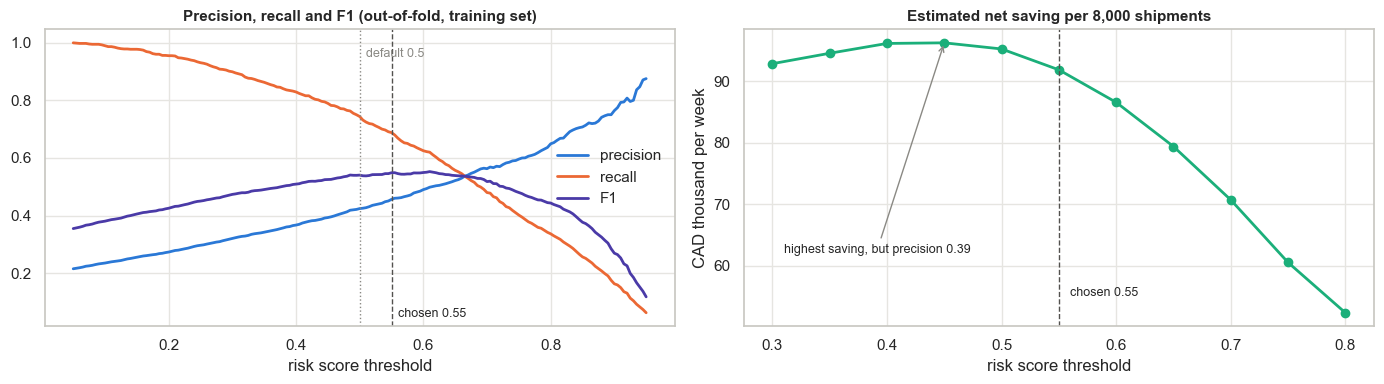

In [26]:
grid = np.linspace(0.05, 0.95, 181)
curves = pd.DataFrame({
    "threshold": grid,
    "precision": [precision_score(y_train, oof_score >= t, zero_division=0) for t in grid],
    "recall": [recall_score(y_train, oof_score >= t) for t in grid],
    "f1": [f1_score(y_train, oof_score >= t) for t in grid],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for col, colour, label in [("precision", ON_TIME, "precision"), ("recall", LATE, "recall"), ("f1", "#4a3aa7", "F1")]:
    axes[0].plot(curves["threshold"], curves[col], color=colour, lw=2, label=label)
axes[0].axvline(CHOSEN_THRESHOLD, color="#52514e", ls="--", lw=1)
axes[0].axvline(0.5, color=NEUTRAL, ls=":", lw=1)
axes[0].text(CHOSEN_THRESHOLD + 0.01, 0.05, f"chosen {CHOSEN_THRESHOLD:.2f}", fontsize=9)
axes[0].text(0.51, 0.95, "default 0.5", fontsize=9, color=NEUTRAL)
axes[0].set_xlabel("risk score threshold")
axes[0].set_title("Precision, recall and F1 (out-of-fold, training set)")
axes[0].legend(frameon=False, loc="center right")

axes[1].plot(threshold_table["threshold"], threshold_table["net_saving_per_week_CAD"] / 1000, color="#1baf7a", lw=2, marker="o", ms=6)
axes[1].axvline(CHOSEN_THRESHOLD, color="#52514e", ls="--", lw=1)
best_any = threshold_table.loc[threshold_table["net_saving_per_week_CAD"].idxmax()]
axes[1].annotate(f"highest saving, but precision {best_any.precision:.2f}",
                 xy=(best_any.threshold, best_any.net_saving_per_week_CAD / 1000),
                 xytext=(0.31, 62),
                 arrowprops=dict(arrowstyle="->", color=NEUTRAL), fontsize=9)
axes[1].set_xlabel("risk score threshold")
axes[1].text(CHOSEN_THRESHOLD + 0.01, 55, f"chosen {CHOSEN_THRESHOLD:.2f}", fontsize=9)
axes[1].set_ylabel("CAD thousand per week")
axes[1].set_title("Estimated net saving per 8,000 shipments")
fig.tight_layout()
plt.show()

**Finding: I chose a threshold of 0.55.**

* The saving curve is quite flat between 0.35 and 0.55. The very top of the curve is at 0.45, but there the precision is only 0.39, which means about three false alarms for every two real problems. Dispatchers who get that many wrong alerts usually start ignoring them.
* At 0.55 the alerts are right about 46% of the time and still catch about 69% of late shipments. It keeps roughly 95% of the maximum possible saving (CAD 91,900 against 96,300 a week) while sending about 800 fewer alerts per week than the 0.45 option.
* It is also next to the threshold with the best F1 (0.549 at 0.55 against 0.550 at 0.60), so two different ways of looking at the problem point to the same place.

The threshold is a business setting, not a fixed part of the model. If dispatch has more people, or if the real cost of a late delivery is higher than I assumed, it should move lower.

## 13. Model evaluation on the test set

Now, for the first time, I use the 1,200 test shipments. Both models are trained on the full training set and compared on exactly the same shipments.

In [27]:
baseline.fit(X_train, y_train)
dummy.fit(X_train, y_train)

base_score = baseline.predict_proba(X_test)[:, 1]
final_score = final_model.predict_proba(X_test)[:, 1]

def test_metrics(name, score, threshold):
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"model": name, "threshold": threshold,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, score) if np.ptp(score) > 0 else 0.5,
            "pr_auc": average_precision_score(y_test, score),
            "late_caught (TP)": tp, "late_missed (FN)": fn, "false_alarms (FP)": fp}

test_results = pd.DataFrame([
    test_metrics("Dummy (always on time)", dummy.predict_proba(X_test)[:, 1], 0.5),
    test_metrics("Baseline LR", base_score, 0.5),
    test_metrics("Final LR (balanced, selected)", final_score, 0.5),
    test_metrics("Final LR (balanced, selected)", final_score, CHOSEN_THRESHOLD),
]).set_index(["model", "threshold"]).round(3)
test_results

accuracy  precision  recall     f1  roc_auc  pr_auc  late_caught (TP)  late_missed (FN)  false_alarms (FP)
model                         threshold                                                                                                            
Dummy (always on time)        0.50          0.794      0.000   0.000  0.000    0.500   0.206                 0               247                  0
Baseline LR                   0.50          0.835      0.696   0.352  0.468    0.829   0.600                87               160                 38
Final LR (balanced, selected) 0.50          0.754      0.442   0.741  0.554    0.838   0.615               183                64                231
                              0.55          0.784      0.483   0.704  0.573    0.838   0.615               174                73                186

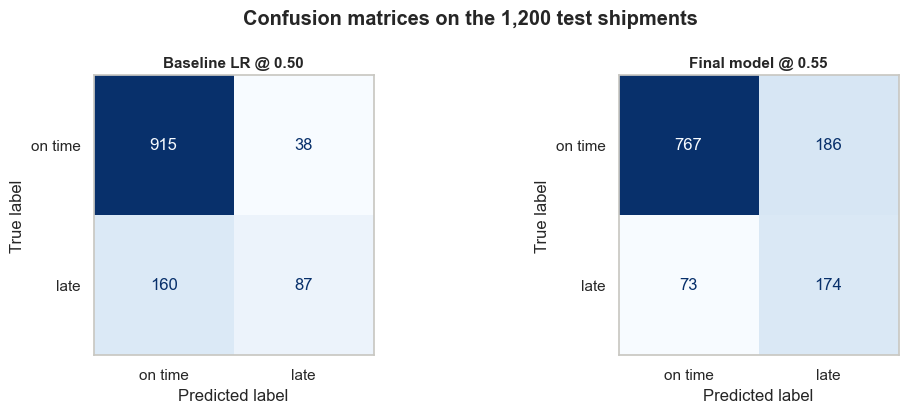

Classification report, final model @ 0.55

              precision    recall  f1-score   support

     on time      0.913     0.805     0.856       953
        late      0.483     0.704     0.573       247

    accuracy                          0.784      1200
   macro avg      0.698     0.755     0.714      1200
weighted avg      0.825     0.784     0.797      1200



In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (title, score, thr) in zip(axes, [("Baseline LR @ 0.50", base_score, 0.5),
                                          (f"Final model @ {CHOSEN_THRESHOLD:.2f}", final_score, CHOSEN_THRESHOLD)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, (score >= thr).astype(int)),
                           display_labels=["on time", "late"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    ax.grid(False)
fig.suptitle("Confusion matrices on the 1,200 test shipments", fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Classification report, final model @ {CHOSEN_THRESHOLD:.2f}\n")
print(classification_report(y_test, (final_score >= CHOSEN_THRESHOLD).astype(int),
                            target_names=["on time", "late"], digits=3))

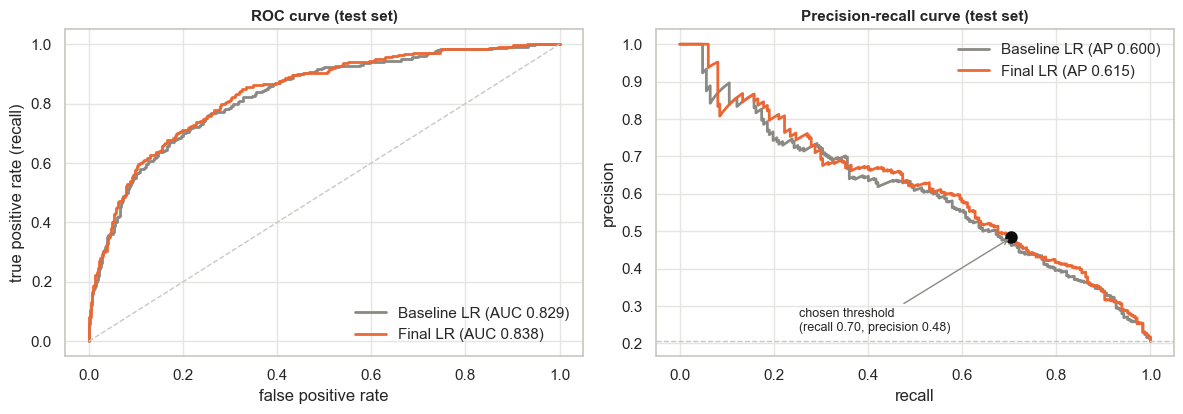

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for name, score, colour in [("Baseline LR", base_score, NEUTRAL), ("Final LR", final_score, LATE)]:
    fpr, tpr, _ = roc_curve(y_test, score)
    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[0].plot(fpr, tpr, color=colour, lw=2, label=f"{name} (AUC {roc_auc_score(y_test, score):.3f})")
    axes[1].plot(rec, prec, color=colour, lw=2, label=f"{name} (AP {average_precision_score(y_test, score):.3f})")
axes[0].plot([0, 1], [0, 1], color="#c9c8c3", ls="--", lw=1)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate (recall)")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
for ax in axes:
    ax.legend(frameon=False, loc="lower right" if ax is axes[0] else "upper right")
axes[1].axhline(y_test.mean(), color="#c9c8c3", ls="--", lw=1)
p_at = precision_score(y_test, final_score >= CHOSEN_THRESHOLD)
r_at = recall_score(y_test, final_score >= CHOSEN_THRESHOLD)
axes[1].plot(r_at, p_at, "o", color="#0b0b0b", ms=8)
axes[1].annotate(f"chosen threshold\n(recall {r_at:.2f}, precision {p_at:.2f})", xy=(r_at, p_at),
                 xytext=(r_at - 0.45, p_at - 0.25), arrowprops=dict(arrowstyle="->", color=NEUTRAL), fontsize=9)
axes[0].set_title("ROC curve (test set)")
axes[1].set_title("Precision-recall curve (test set)")
fig.tight_layout()
plt.show()

In [30]:
base_tp = int(((base_score >= 0.5) & (y_test == 1)).sum())
final_tp = int(((final_score >= CHOSEN_THRESHOLD) & (y_test == 1)).sum())
final_alerts = int((final_score >= CHOSEN_THRESHOLD).sum())
scale = WEEKLY_SHIPMENTS / len(y_test)
print(f"Late shipments in the test set:          {int(y_test.sum())}")
print(f"Caught by the baseline (@0.50):          {base_tp}")
print(f"Caught by the final model (@{CHOSEN_THRESHOLD:.2f}):       {final_tp}  ({final_tp / base_tp:.1f}x the baseline)")
print(f"\nScaled to {WEEKLY_SHIPMENTS:,} shipments a week:")
print(f"  about {final_alerts * scale:,.0f} alerts, of which about {final_tp * scale:,.0f} are real late shipments caught early")
print(f"  versus {base_tp * scale:,.0f} caught by the baseline")

Late shipments in the test set:          247
Caught by the baseline (@0.50):          87
Caught by the final model (@0.55):       174  (2.0x the baseline)

Scaled to 8,000 shipments a week:
  about 2,400 alerts, of which about 1,160 are real late shipments caught early
  versus 580 caught by the baseline


**Finding.** The test results match the cross-validation results closely, so the model is not overfitting.

* The **baseline** looks safe with 83.5% accuracy, but it only catches 87 of the 247 late shipments (recall 0.35). Dispatch would still be surprised by about two late loads out of three.
* The **final model at 0.55** catches 174 late shipments (recall 0.70), exactly **twice as many** as the baseline. Precision is 0.48, so roughly one alert in two is a real problem. F1 improves from 0.47 to 0.57.
* Accuracy goes down from 83.5% to 78.4%. That is the expected price of catching more late shipments, and it is why accuracy is the wrong metric for this problem.
* ROC-AUC of 0.84 means that if I pick one late and one on-time shipment at random, the model gives the late one a higher score about 84% of the time.
* At MapleFreight's volume this works out to about 2,400 alerts a week, catching around 1,160 late shipments early instead of 580 with the baseline.

## 14. Model explainability

Dispatch will only act on alerts they trust, so I want to show **why** the model flags a shipment. Because the final model is a logistic regression on scaled inputs, each coefficient tells me how much one standard deviation (or one category) changes the log-odds of being late. I also check the result with permutation importance, which is model-agnostic.

### 14.1 Global drivers

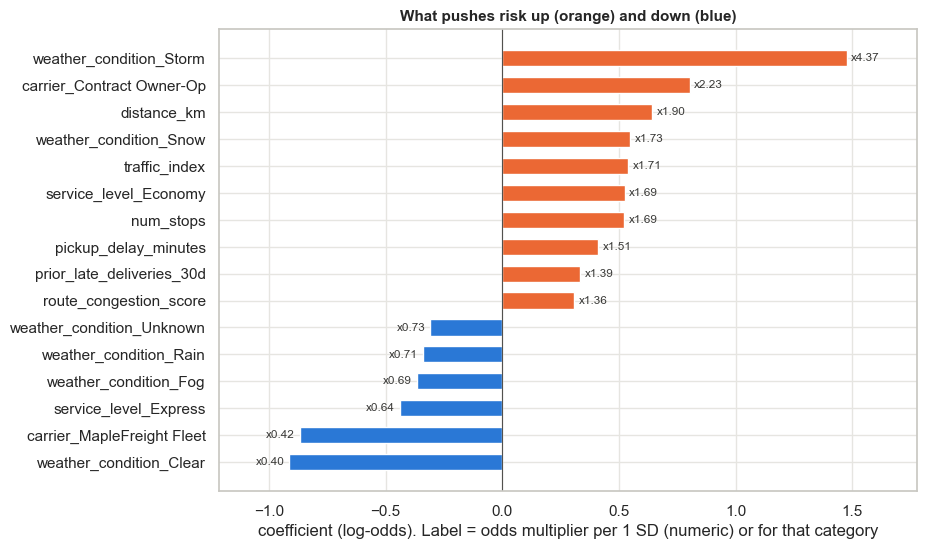

In [31]:
prep = final_model.named_steps["prep"]
clf = final_model.named_steps["model"]
feature_names = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
coefs = pd.Series(clf.coef_[0], index=feature_names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(16).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=[LATE if v > 0 else ON_TIME for v in top.values], height=0.6)
ax.axvline(0, color="#52514e", lw=0.8)
for i, v in enumerate(top.values):
    ax.text(v + (0.02 if v > 0 else -0.02), i, f"x{np.exp(v):.2f}", va="center",
            ha="left" if v > 0 else "right", fontsize=8.5, color="#3a3a38")
ax.set_xlim(top.min() - 0.3, top.max() + 0.3)
ax.set_xlabel("coefficient (log-odds). Label = odds multiplier per 1 SD (numeric) or for that category")
ax.set_title("What pushes risk up (orange) and down (blue)")
plt.show()

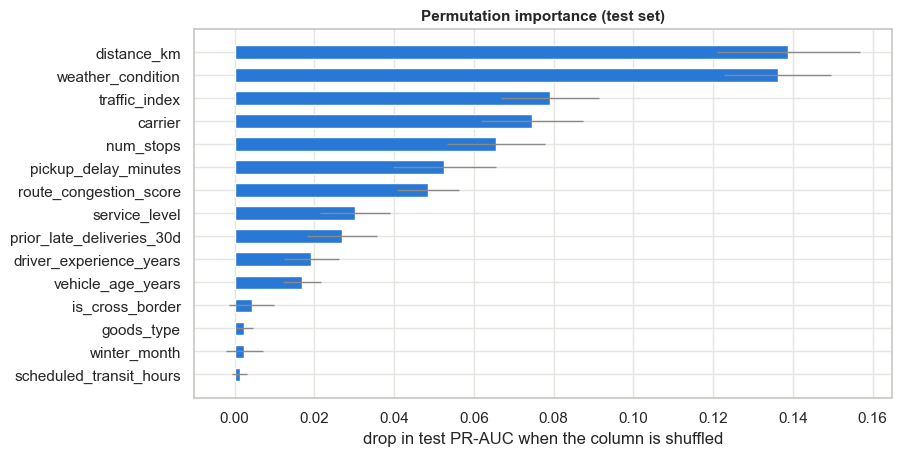

In [32]:
perm = permutation_importance(final_model, X_test, y_test, scoring="average_precision",
                              n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = (pd.DataFrame({"feature": X_test.columns, "drop_in_pr_auc": perm.importances_mean, "std": perm.importances_std})
              .query("feature in @SEL_CAT or feature in @SEL_NUM")
              .sort_values("drop_in_pr_auc"))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(perm_imp["feature"], perm_imp["drop_in_pr_auc"], xerr=perm_imp["std"], color=ON_TIME, height=0.6,
        error_kw=dict(ecolor=NEUTRAL, lw=1))
ax.set_xlabel("drop in test PR-AUC when the column is shuffled")
ax.set_title("Permutation importance (test set)")
plt.show()

**Finding.** The two methods agree on the main drivers.

* **Distance and the weather forecast** are the most important inputs. Shuffling either one lowers the test PR-AUC by about 0.14. A storm forecast has the largest single coefficient in the model, and a clear forecast is the strongest protective condition.
* **Traffic, carrier, number of stops, pickup delay and route congestion** come next. One standard deviation more traffic (about 18 points) multiplies the odds of being late by about 1.7, and so does one standard deviation more stops (about 1.7 stops). Among carriers, contract owner-operators raise the risk the most and the company's own fleet clearly lowers it.
* **Driver experience** is the main protective numeric factor: each extra 4.7 years (one standard deviation) cuts the odds by about a quarter.
* Express service lowers the odds and Economy raises them.
* `scheduled_transit_hours` adds almost nothing once distance is in the model, because the two columns are 93% correlated.

None of the important features are surprising, which is a good sign. The model has learned patterns that a dispatcher would recognise, not a strange artefact of the data.

### 14.2 Why was this shipment flagged?

For a linear model, the contribution of each input is simply coefficient x (value minus the training average). This is the same as a SHAP value for a linear model, so I can explain single predictions without an extra library. I group the one-hot columns back to their original feature.

In [33]:
train_mean = prep.transform(X_train).mean(axis=0)

def original_feature(name):
    for col in SEL_CAT:
        if name.startswith(col + "_"):
            return col
    return name

GROUP = [original_feature(n) for n in feature_names]

def contributions(rows):
    """Per-shipment contribution of each original feature to the log-odds of being late."""
    z = (prep.transform(rows) - train_mean) * clf.coef_[0]
    return pd.DataFrame(z, columns=feature_names, index=rows.index).T.groupby(GROUP).sum().T

board = X_test.copy()
board["risk_score"] = final_score
board["actually_late"] = y_test
example = board.sort_values("risk_score", ascending=False).head(1)
ex_contrib = contributions(example[X_train.columns]).iloc[0].sort_values(ascending=False)

print(f"Shipment {example['shipment_id'].iloc[0]}  risk score {example['risk_score'].iloc[0]:.2f}  "
      f"(actually late: {'yes' if example['actually_late'].iloc[0] == 1 else 'no'})")
def tidy(v):
    return f"{v + 0.0:,.2f}".rstrip("0").rstrip(".") if isinstance(v, float) else str(v)

pd.DataFrame({"value": [tidy(example[c].iloc[0]) for c in ex_contrib.index],
              "contribution_to_log_odds": ex_contrib.round(3)}, index=ex_contrib.index)

Shipment SHP-100936  risk score 0.98  (actually late: yes)


,value,contribution_to_log_odds
weather_condition,Storm,1.879
distance_km,"1,511.6",1.789
num_stops,5,0.774
traffic_index,78.1,0.713
carrier,PrairieLine,0.491
route_congestion_score,0.54,0.139
vehicle_age_years,6.1,0.032
service_level,Standard,-0.000
is_cross_border,0,-0.064
goods_type,Hazardous,-0.067


**Finding.** The highest-risk shipment in the test set (SHP-100936, risk score 0.98) was flagged because of a storm forecast, a 1,512 km route, 5 stops, traffic of 78/100 and a PrairieLine truck. An on-time pickup and a carrier with no recent late deliveries pulled the score down a little, but not enough. It really was late. I reuse this logic in the Slack alert: each flagged shipment comes with its top two reasons in plain words, so the dispatcher knows what to check first.

## 15. Slack alert integration

**Setup (done once):**
1. Create a free Slack workspace and a channel called `#dispatch-alerts`.
2. Create a Slack app at api.slack.com/apps, turn on **Incoming Webhooks** and add a webhook to `#dispatch-alerts`.
3. Copy `.env.example` to `.env` and paste the webhook URL into it. `.env` is listed in `.gitignore`, so the URL never reaches GitHub.

**How it works in this notebook:** the 1,200 test shipments stand in for "today's in-transit board". At 8,000 shipments a week this is roughly one day of volume. Every shipment gets a risk score, and the ones at or above the chosen threshold are counted. The message shows the count first and then the top five with ID, destination, carrier, risk score and the two main reasons, so it is quick to read on a phone.

The webhook URL is loaded into a variable and never printed. If the `.env` file is missing, the code prints a preview instead of failing.

In [34]:
load_dotenv(".env")  # reads .env from the notebook folder; does nothing if the file is missing
SLACK_WEBHOOK_URL = os.getenv("SLACK_WEBHOOK_URL", "").strip()
print("Slack webhook found in environment:", "yes" if SLACK_WEBHOOK_URL else "no (preview mode, nothing will be sent)")

Slack webhook found in environment: yes


In [35]:
def describe_reason(feature, r):
    """Turn a model feature and the shipment's value into a short phrase for dispatch."""
    def num(v, fmt):
        return "unknown" if pd.isna(v) else format(v, fmt)
    phrases = {
        "carrier": "owner-operator carrier" if r["carrier"] == "Contract Owner-Op" else f"{r['carrier']} carrier",
        "weather_condition": f"{str(r['weather_condition']).lower()} forecast",
        "num_stops": f"{int(r['num_stops'])} stops",
        "pickup_delay_minutes": f"picked up {num(r['pickup_delay_minutes'], '.0f')} min late",
        "traffic_index": f"traffic {num(r['traffic_index'], '.0f')}/100",
        "distance_km": f"long route ({num(r['distance_km'], ',.0f')} km)",
        "scheduled_transit_hours": f"{num(r['scheduled_transit_hours'], '.1f')} h trip",
        "prior_late_deliveries_30d": f"carrier late {int(r['prior_late_deliveries_30d'])}x in 30 days",
        "route_congestion_score": f"congested route ({num(r['route_congestion_score'], '.2f')})",
        "driver_experience_years": f"driver {num(r['driver_experience_years'], '.1f')} yrs experience",
        "vehicle_age_years": f"truck {num(r['vehicle_age_years'], '.0f')} yrs old",
        "service_level": f"{r['service_level']} service",
        "goods_type": f"{str(r['goods_type']).lower()} load",
        "is_cross_border": "cross-border",
        "winter_month": "winter month",
    }
    return phrases.get(feature, feature)

def top_reasons(rows, n=2):
    contrib = contributions(rows[X_train.columns])
    out = []
    for idx, c in contrib.iterrows():
        feats = [f for f in c.sort_values(ascending=False).index if c[f] > 0][:n]
        out.append(", ".join(describe_reason(f, rows.loc[idx]) for f in feats))
    return out

at_risk = board[board["risk_score"] >= CHOSEN_THRESHOLD].sort_values("risk_score", ascending=False).copy()
at_risk["reasons"] = top_reasons(at_risk)
print(f"{len(at_risk)} of {len(board):,} shipments are at or above the {CHOSEN_THRESHOLD:.2f} threshold.\n")
at_risk[["shipment_id", "destination_city", "carrier", "risk_score", "reasons"]].head(10).round(2)

360 of 1,200 shipments are at or above the 0.55 threshold.



,shipment_id,destination_city,carrier,risk_score,reasons
5268,SHP-100936,Calgary AB,PrairieLine,0.98,"storm forecast, long route (1,512 km)"
1555,SHP-103230,Regina SK,Contract Owner-Op,0.98,"owner-operator carrier, snow forecast"
3041,SHP-105511,Ottawa ON,NorthStar Carriers,0.98,"traffic 91/100, snow forecast"
2110,SHP-102910,Edmonton AB,QuebecExpress,0.98,"storm forecast, long route (1,148 km)"
554,SHP-103300,Winnipeg MB,NorthStar Carriers,0.97,"snow forecast, picked up 81 min late"
3632,SHP-100273,Hamilton ON,NorthStar Carriers,0.97,"long route (1,594 km), snow forecast"
1481,SHP-104995,Winnipeg MB,NorthStar Carriers,0.97,"storm forecast, traffic 82/100"
955,SHP-101710,Sudbury ON,MapleFreight Fleet,0.96,"long route (1,898 km), storm forecast"
504,SHP-103708,Winnipeg MB,PrairieLine,0.96,"storm forecast, picked up 79 min late"
939,SHP-101673,Sudbury ON,Contract Owner-Op,0.96,"owner-operator carrier, snow forecast"


In [36]:
CRITICAL_SCORE = 0.85  # a second, stricter level so dispatch knows where to start

def build_alert_message(at_risk, total, threshold, top_n=5):
    now = datetime.now().strftime("%a %d %b %Y, %H:%M")
    n_critical = int((at_risk["risk_score"] >= CRITICAL_SCORE).sum())
    by_carrier = at_risk["carrier"].value_counts().head(2)
    lines = [
        ":rotating_light: *MapleFreight late-delivery alert*",
        f"*{len(at_risk)} of {total:,}* in-transit shipments are at high risk of missing their window "
        f"(risk score ≥ {threshold:.2f}).",
        f":red_circle: *{n_critical}* are critical (≥ {CRITICAL_SCORE:.2f}), start with these.",
        "Most flagged carriers: " + ", ".join(f"{c} ({n})" for c, n in by_carrier.items()),
        "",
        f"*Top {min(top_n, len(at_risk))} to check now:*",
    ]
    for i, r in enumerate(at_risk.head(top_n).itertuples(), start=1):
        lines.append(f"{i}. `{r.shipment_id}` → {r.destination_city} | {r.carrier} | *{r.risk_score:.2f}*")
        lines.append(f"      _{r.reasons}_")
    lines += ["", "Please re-route or call the customer before the delivery window closes.",
              f"_Logistic regression model, threshold {threshold:.2f}. Sent {now}_"]
    return "\n".join(lines)

def send_slack_alert(message, webhook_url, timeout=10):
    """Post the message to Slack. The webhook URL is never printed."""
    if not webhook_url:
        print("No SLACK_WEBHOOK_URL set, so the message was NOT sent. Add it to .env and re-run this cell.")
        return None
    if not webhook_url.startswith("https://hooks.slack.com/"):
        raise ValueError("SLACK_WEBHOOK_URL does not look like a Slack incoming webhook URL.")
    response = requests.post(webhook_url, json={"text": message}, timeout=timeout)
    print(f"Slack response: HTTP {response.status_code} '{response.text}'")
    response.raise_for_status()
    return response.status_code

message = build_alert_message(at_risk, total=len(board), threshold=CHOSEN_THRESHOLD)
print("Message preview:\n" + "-" * 60 + "\n" + message + "\n" + "-" * 60)

if len(at_risk) > 0:
    send_slack_alert(message, SLACK_WEBHOOK_URL)
else:
    print("No shipments above the threshold, so no alert was sent.")

Message preview:
------------------------------------------------------------
:rotating_light: *MapleFreight late-delivery alert*
*360 of 1,200* in-transit shipments are at high risk of missing their window (risk score ≥ 0.55).
:red_circle: *83* are critical (≥ 0.85), start with these.
Most flagged carriers: PrairieLine (86), MapleFreight Fleet (75)

*Top 5 to check now:*
1. `SHP-100936` → Calgary AB | PrairieLine | *0.98*
      _storm forecast, long route (1,512 km)_
2. `SHP-103230` → Regina SK | Contract Owner-Op | *0.98*
      _owner-operator carrier, snow forecast_
3. `SHP-105511` → Ottawa ON | NorthStar Carriers | *0.98*
      _traffic 91/100, snow forecast_
4. `SHP-102910` → Edmonton AB | QuebecExpress | *0.98*
      _storm forecast, long route (1,148 km)_
5. `SHP-103300` → Winnipeg MB | NorthStar Carriers | *0.97*
      _snow forecast, picked up 81 min late_

Please re-route or call the customer before the delivery window closes.
_Logistic regression model, threshold 0.55. Sent 

**Finding.** The alert gives dispatch what they need in one glance: how big the problem is today, which carriers are behind most of it, and the five loads to look at first, each with a reason they can check (for example a storm forecast or a late pickup). A screenshot of the message as it appeared in `#dispatch-alerts` is saved in `screenshots/slack_alert.png`.

In production, this cell would run on a schedule (for example every hour from 6 am) on the shipments that have just been dispatched, instead of on the test set.

## 16. Recommendations

**For operations**

1. **Review the owner-operator contracts.** Contract owner-operators are late on 36% of loads, almost three times the company fleet (13%). Add on-time clauses to their contracts, or move time-sensitive loads (Express, refrigerated, Gold customers) to the company fleet or NorthStar.
2. **Plan around the weather forecast.** Snow and storm forecasts push the late rate to 34% and 46%. For those days, add buffer time to the promised window, or warn the customer at booking instead of after the fact.
3. **Treat a late pickup as an early warning.** Shipments picked up more than 30 minutes late arrive late about 27% of the time (34% when the pickup is over 90 minutes late), against 15% for on-time pickups. Dispatch should get an automatic check whenever a pickup is 30+ minutes late, without waiting for the model.
4. **Limit stops on tight schedules.** Every extra stop adds risk (12% with zero stops, 29% with five). Routes with four or more stops should get more scheduled time or be split.
5. **Pair less experienced drivers with easier routes.** Driver experience is the strongest protective factor. New drivers should not get long, multi-stop, high-traffic runs in winter.
6. **Use the carrier's recent record.** Carriers with 3 or more late deliveries in the past 30 days are much more likely to be late again. A weekly carrier scorecard would make this visible to the account managers.
7. **Look at priority tiers.** Gold customers currently get the same on-time rate as Bronze customers. If Gold contracts carry bigger guarantees, these loads should be given the lower-risk carriers and service levels first.

**For the alert system**

8. Start with the 0.55 threshold, then review it monthly with real cost data from finance. Lower it if dispatch has spare capacity.
9. Track what dispatch does with each alert (re-routed, customer called, ignored). This data will show which actions actually prevent late deliveries and can be used to improve the model later.

## 17. Limitations and next steps

* **Random split, not a time split.** The data has a month but no year or date, so I could not test the model on a later time period. In production I would train on past months and test on the next one.
* **Risk scores are not exact probabilities.** Class weighting makes the scores higher than the true chance of being late. They work well for ranking and for the threshold, but if dispatch wants a real percentage, the model should be calibrated first (for example with `CalibratedClassifierCV`).
* **Cost figures are assumptions.** The threshold choice depends on them. Real numbers from finance would make the decision stronger.
* **Prediction is made at dispatch only.** Live GPS position, updated ETA and driver hours of service would allow the risk to be updated during the trip, which should improve recall a lot.
* **Model upkeep.** Carriers and routes change. The model should be retrained every month and its precision and recall tracked, so it does not quietly get worse.